In [1]:
# Import PPI

import pandas as pd
import networkx as nx

df = pd.read_csv("PPI_physical_elist.csv", header=None)
df.columns = ['protein1', 'protein2'] 

G = nx.from_pandas_edgelist(df, source='protein1', target='protein2')

In [2]:
# Check size of PPI and change node names to str

print(len(G.edges()))
print(len(G.nodes()))

nx.relabel_nodes(G, lambda x: str(x), copy=False)

first_node = next(iter(G.nodes))
print(type(first_node))

for i, component in enumerate(nx.connected_components(G), 1):
    print(f"Component {i}: {len(component)} nodes")

306914
18068
<class 'str'>
Component 1: 18064 nodes
Component 2: 4 nodes


In [4]:
# Read disease modules

import pickle

with open('d_doup_genes.pkl', 'rb') as file:
    disease_genes = pickle.load(file)

#print(disease_genes)

In [5]:
# Number of diseases
len(disease_genes)

3911

In [6]:
# Function to compute some graph stats

import networkx as nx

def print_graph_stats(G):
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())
    degrees = [deg for _, deg in G.degree()]
    print("Max degree:", max(degrees))
    print("Min degree:", min(degrees))
    print("Average clustering coefficient:", nx.average_clustering(G) if not G.is_directed() else "N/A")
    print("Diameter:", nx.diameter(G) if nx.is_connected(G) else "graph is not connected")


print_graph_stats(G)

Number of nodes: 18068
Number of edges: 306914
Average degree: 33.97321230905468
Max degree: 2344
Min degree: 1
Average clustering coefficient: 0.07852682740590607
Diameter: graph is not connected


In [ ]:
# Function to compute largest connected component of given disease

def compute_lcc_of_disease(disease_id):
    subgraph_nodes = disease_genes[disease_id]
    subgraph = G.subgraph(subgraph_nodes).copy()

    try:
        largest_cc_nodes = max(nx.connected_components(subgraph), key=len)
        largest_cc_subgraph = subgraph.subgraph(largest_cc_nodes).copy()
        return largest_cc_nodes, largest_cc_subgraph
    
    except ValueError as e:
        return None, None

In [10]:
# Compute size of lcc for all diseases

from collections import Counter

disease_lengths = []

for disease in disease_genes.keys():
    nodes, _ = compute_lcc_of_disease(disease)
    if nodes is not None:
        disease_lengths.append(len(nodes))

gene_size_counts = Counter(disease_lengths)
print(gene_size_counts)

Counter({1: 1936, 2: 486, 3: 255, 4: 200, 5: 81, 7: 61, 6: 55, 13: 46, 25: 40, 9: 38, 41: 37, 8: 32, 16: 30, 19: 30, 10: 26, 15: 24, 21: 19, 17: 18, 20: 18, 23: 17, 26: 17, 50: 16, 14: 15, 12: 13, 24: 11, 32: 8, 11: 7, 44: 7, 35: 7, 18: 7, 43: 6, 39: 6, 94: 6, 88: 6, 36: 5, 42: 5, 133: 5, 57: 5, 28: 5, 29: 5, 75: 5, 49: 4, 64: 4, 125: 4, 95: 4, 46: 4, 104: 4, 22: 4, 30: 4, 73: 4, 146: 3, 27: 3, 127: 3, 85: 3, 139: 3, 67: 3, 34: 3, 112: 3, 48: 3, 37: 3, 89: 3, 158: 3, 244: 2, 350: 2, 588: 2, 409: 2, 412: 2, 99: 2, 157: 2, 155: 2, 149: 2, 53: 2, 45: 2, 443: 2, 453: 2, 47: 2, 92: 2, 284: 2, 150: 2, 154: 2, 196: 2, 153: 2, 181: 2, 141: 2, 241: 2, 188: 2, 243: 2, 81: 2, 33: 2, 98: 2, 86: 2, 115: 2, 118: 2, 55: 2, 59: 2, 70: 2, 108: 2, 109: 2, 123: 2, 68: 1, 203: 1, 2192: 1, 2294: 1, 2430: 1, 6294: 1, 396: 1, 4030: 1, 209: 1, 852: 1, 602: 1, 694: 1, 383: 1, 498: 1, 276: 1, 232: 1, 597: 1, 709: 1, 1263: 1, 258: 1, 405: 1, 210: 1, 370: 1, 285: 1, 326: 1, 164: 1, 954: 1, 2287: 1, 697: 1, 422: 1

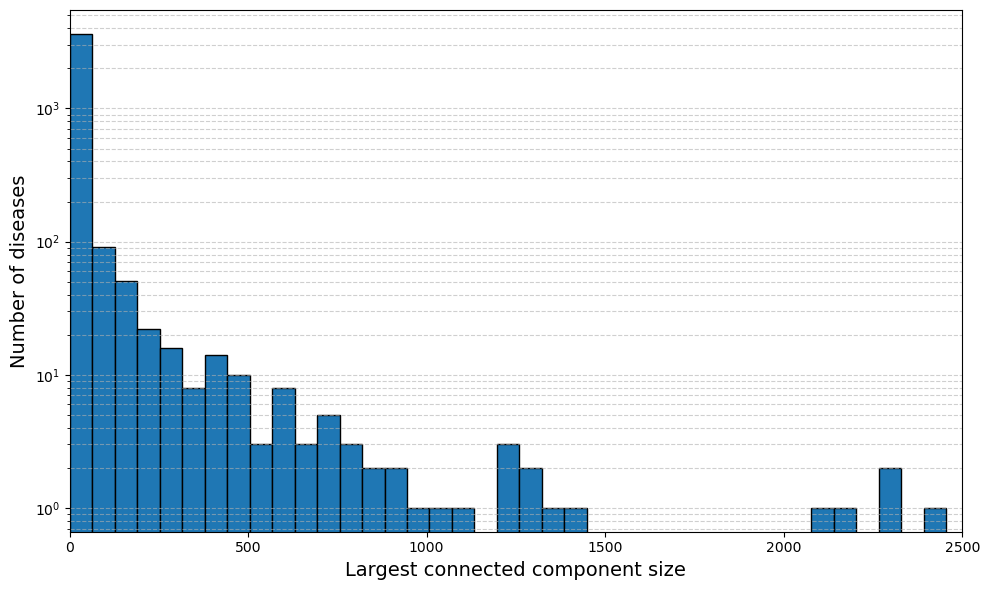

In [84]:
# Plot lcc size distribution

import matplotlib.pyplot as plt
import numpy as np

data = []
for size, count in gene_size_counts.items():
    data.extend([size] * count)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, edgecolor='black')
plt.xlabel('Largest connected component size', fontsize = 14)
plt.ylabel('Number of diseases', fontsize = 14)
plt.yscale('log')
plt.xlim(0,2500)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("lcc_size.png", dpi = 300)
plt.show()

In [14]:
# Import doid to name dictionary

import json

with open("doid_to_name.json", "r") as f:
    doid_to_name = json.load(f)
     
# Make a name to doid dictionary
name_to_doid = {v: k for k, v in doid_to_name.items()}

In [71]:
# Fucntion to compute normalized Laplacian spectrum of given diseases

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from numpy import linalg as LA

def plot_lcc_spectra_overlay_lines(disease_list, name, bins):
    bin_edges = np.linspace(0, 2, bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 6))

    for disease_name in disease_list:
        disease_id = name_to_doid[disease_name]
        largest_lcc_nodes, largest_lcc_subgraph = compute_lcc_of_disease(disease_id)
        
        # Compute normalized Laplacian eigenvalues
        L_lcc = nx.normalized_laplacian_matrix(largest_lcc_subgraph).toarray()
        eigenvalues_lcc, _ = LA.eigh(L_lcc)
        
        # Compute histogram 
        counts, _ = np.histogram(eigenvalues_lcc, bins=bin_edges)
        # Normalize
        counts = counts / np.sum(counts)

        # Plot
        plt.plot(
            bin_centers,
            counts,
            linewidth=2,
            label=disease_name
        )

    plt.xlabel("Eigenvalue", fontsize = 14)
    plt.ylabel("Relative frequency", fontsize = 14)
    plt.xlim(0, 2)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{name}_overlined_spectra.png", dpi = 300)
    plt.show()

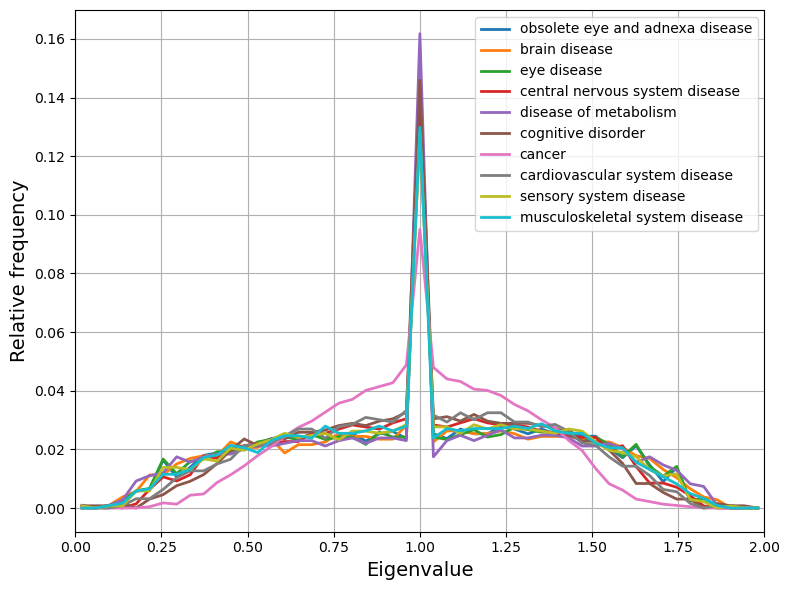

In [ ]:
# Diseases with lcc> 1000 (16, only more generic terms) -- removed the very large general ones i.e., "disease"

lcc_1000_dis = ["obsolete eye and adnexa disease",
"brain disease",
"eye disease",
"central nervous system disease",
"disease of metabolism",
"cognitive disorder",
"cancer",
"cardiovascular system disease",
"sensory system disease",
"musculoskeletal system disease"
]
plot_lcc_spectra_overlay_lines(lcc_1000_dis, "lcc_1000_dis", 52)

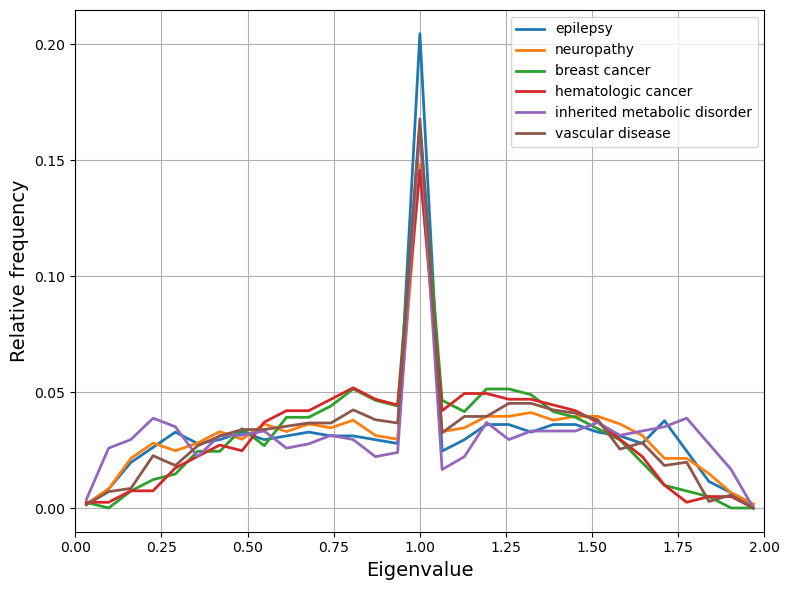

In [76]:
# Diseases with 400 < lcc < 1000

lcc_400_dis = [
"epilepsy",
"neuropathy",
"breast cancer",
"hematologic cancer",
"inherited metabolic disorder", # this is with smallest z-score
"vascular disease" # this is with biggest z-score
]
plot_lcc_spectra_overlay_lines(lcc_400_dis, "lcc_400_dis", 30)

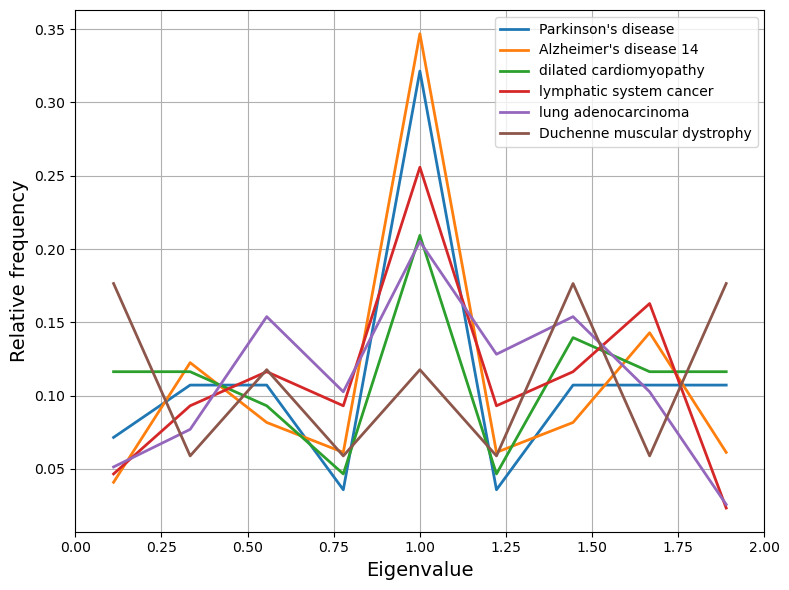

In [75]:
# Diseases with 10 < lcc < 50 and zscore > 10

selected_diseases_10_50_10_30 = [
    "Parkinson's disease",
    "Alzheimer's disease 14",
    "dilated cardiomyopathy",
    'lymphatic system cancer',
    "lung adenocarcinoma",
    "Duchenne muscular dystrophy",
]
plot_lcc_spectra_overlay_lines(selected_diseases_10_50_10_30, "selected_diseases_10_50_10_30", 10)

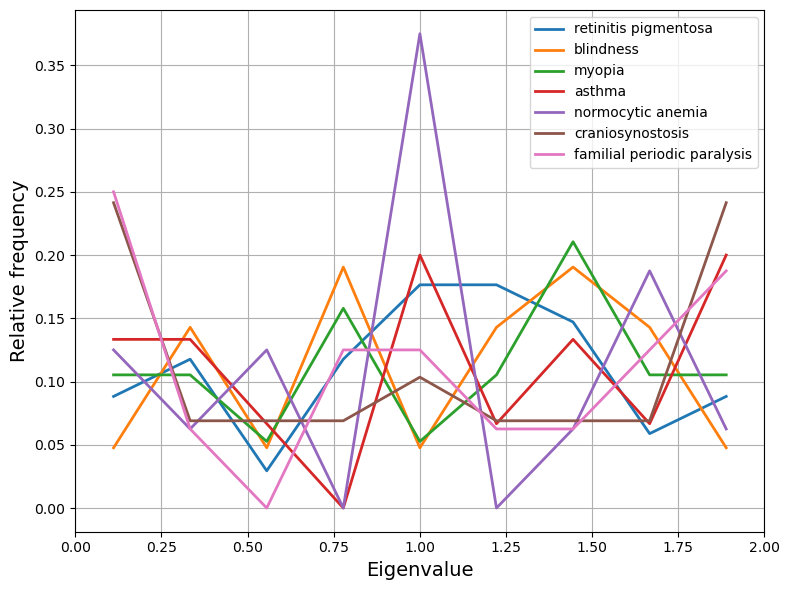

In [74]:
# Diseases with 10 < lcc < 50 and zscore < 10

selected_diseases_10_50_1_5 = [
    "retinitis pigmentosa",
    "blindness",
    "myopia",
    "asthma",
    "normocytic anemia",
    "craniosynostosis",
    "familial periodic paralysis"
]
plot_lcc_spectra_overlay_lines(selected_diseases_10_50_1_5, "selected_diseases_10_50_1_5", 10)

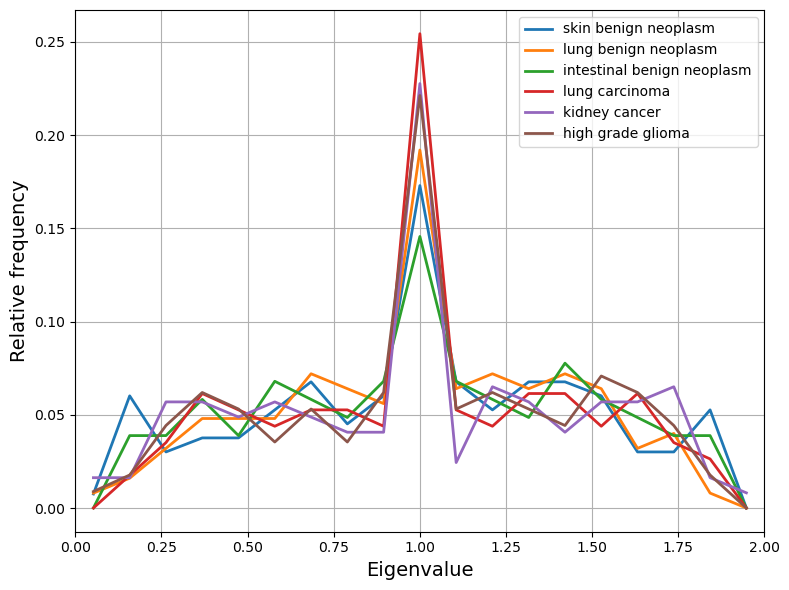

In [85]:
# Diseases with 100 < lcc < 200 and zscore > 10

selected_diseases_100_200_10_20= [
    "skin benign neoplasm",
    "lung benign neoplasm",
    "intestinal benign neoplasm",
    "lung carcinoma",
    "kidney cancer",
    "high grade glioma"
]
plot_lcc_spectra_overlay_lines(selected_diseases_100_200_10_20, "selected_diseases_100_200_10_20", 20)

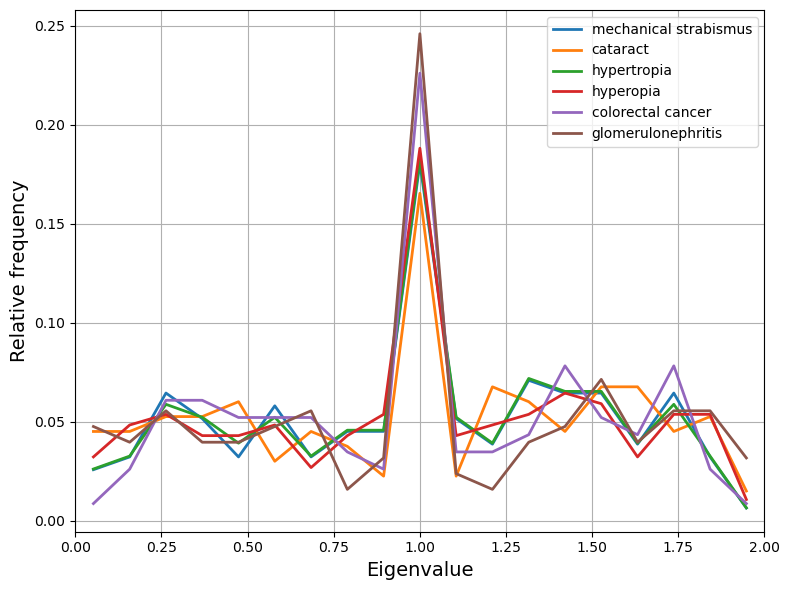

In [72]:
# Diseases with 100 < lcc < 200 and zscore < 10

selected_diseases_100_200_3_10= [
    "mechanical strabismus",
    "cataract",
    "hypertropia",
    "hyperopia",
    "colorectal cancer",
    "glomerulonephritis"
]
plot_lcc_spectra_overlay_lines(selected_diseases_100_200_3_10, "selected_diseases_100_200_3_10", 20)

In [114]:
# Function to plot lcc graph of given diseases


from numpy import linalg as LA

def plot_lcc_of_given_disease(disease_name):
    disease_id = name_to_doid[disease_name]
    largest_lcc_nodes, largest_lcc_subgraph = compute_lcc_of_disease(disease_id)
    print("Number of nodes in whole disease graph:", len(disease_genes[disease_id]))
    print(print_graph_stats(largest_lcc_subgraph))

    pos = nx.spring_layout(largest_lcc_subgraph, seed=35)  #35 for craniosynostosis, 50 for blindness 
    plt.figure(figsize=(6, 4))

    # Plot the graph
    nx.draw(
        largest_lcc_subgraph,
        pos = pos,
        with_labels=False,
        node_color='blue',
        edge_color='gray',
        node_size=200
    )

    plt.tight_layout()
    plt.savefig("craniosynostosis_lcc.png", dpi = 300)
    plt.show()


Number of nodes in whole disease graph: 159
Number of nodes: 29
Number of edges: 28
Average degree: 1.9310344827586208
Max degree: 4
Min degree: 1
Average clustering coefficient: 0.0
Diameter: 20
None


<ipython-input-114-aec0075f0b03>:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


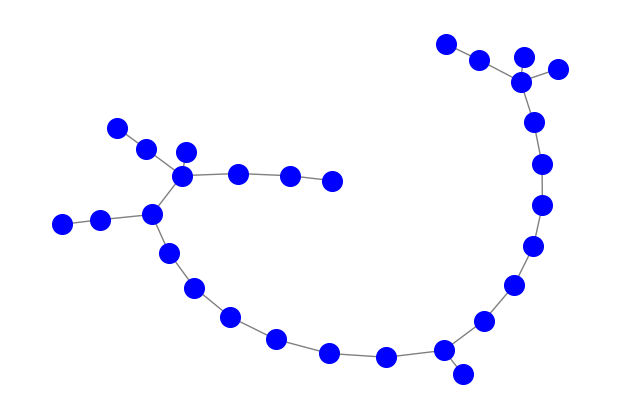

In [115]:
plot_lcc_of_given_disease("craniosynostosis")

Number of nodes in whole disease graph: 179
Number of nodes: 22
Number of edges: 39
Average degree: 3.5454545454545454
Max degree: 11
Min degree: 1
Average clustering coefficient: 0.4020562770562771
Diameter: 5
None


<ipython-input-112-69289792374c>:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


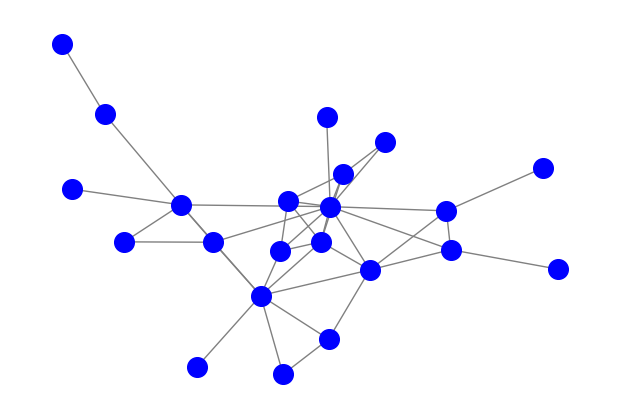

In [113]:
plot_lcc_of_given_disease("blindness")